In [1]:
# Cell 1 - Mount Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
# Cell 2 - Clone و Setup
import os

if not os.path.exists('/content/Website-Fingerprinting-Library'):
    os.system('git clone https://github.com/Xinhao-Deng/Website-Fingerprinting-Library.git')

os.chdir('/content/Website-Fingerprinting-Library')

import sys
sys.path.insert(0, '/content/Website-Fingerprinting-Library')
print("Setup done")

Setup done


In [3]:
# Cell 3 - Install dependencies
!pip install -q torch numpy scikit-learn tqdm pytorch-metric-learning
print("Dependencies installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.8/127.8 kB 12.8 MB/s eta 0:00:00
Dependencies installed


In [4]:
# Cell 4 - Download/Load ARES dataset
import os

os.makedirs('datasets', exist_ok=True)

drive_path = '/content/drive/MyDrive/WF_project/datasets/closed_2tab.npz'
local_path = 'datasets/closed_2tab.npz'

if os.path.exists(local_path):
    print("ARES dataset already exists locally")
elif os.path.exists(drive_path):
    import shutil
    shutil.copy(drive_path, local_path)
    print("ARES dataset copied from Drive")
else:
    !wget -O datasets/closed_2tab.npz.zip "https://zenodo.org/records/13732130/files/closed_2tab.npz.zip?download=1"
    !unzip -q datasets/closed_2tab.npz.zip -d datasets/
    print("ARES dataset downloaded")

print("Done")

ARES dataset copied from Drive
Done


In [5]:
# Cell 5 - Split ARES dataset
import os
os.chdir('/content/Website-Fingerprinting-Library')

train_path = 'datasets/closed_2tab/train.npz'

if os.path.exists(train_path):
    print("Dataset already split")
else:
    !PYTHONPATH=/content/Website-Fingerprinting-Library python \
      exp/dataset_process/dataset_split.py \
      --dataset closed_2tab --use_stratify False
    print("Dataset split done")

loading... ./datasets/closed_2tab.npz
Train: X = (46980, 10000), y = (46980, 100)
Valid: X = (5220, 10000), y = (5220, 100)
Test: X = (5800, 10000), y = (5800, 100)
Dataset split done


In [7]:
# Cell 6 - Generate MTAF features (load from Drive if available)
import os, shutil
os.chdir('/content/Website-Fingerprinting-Library')

drive_mtaf = '/content/drive/MyDrive/WF_project/mtaf'
local_mtaf = 'datasets/closed_2tab'

if os.path.exists(f'{drive_mtaf}/mtaf_train.npz'):
    # Load from Drive
    shutil.copy(f'{drive_mtaf}/mtaf_train.npz', f'{local_mtaf}/mtaf_train.npz')
    shutil.copy(f'{drive_mtaf}/mtaf_valid.npz', f'{local_mtaf}/mtaf_valid.npz')
    shutil.copy(f'{drive_mtaf}/mtaf_test.npz', f'{local_mtaf}/mtaf_test.npz')
    print("MTAF loaded from Drive")
else:
    # Generate
    !PYTHONPATH=/content/Website-Fingerprinting-Library python \
      exp/dataset_process/gen_mtaf.py \
      --dataset closed_2tab --seq_len 10000 --in_file train
    !PYTHONPATH=/content/Website-Fingerprinting-Library python \
      exp/dataset_process/gen_mtaf.py \
      --dataset closed_2tab --seq_len 10000 --in_file valid
    !PYTHONPATH=/content/Website-Fingerprinting-Library python \
      exp/dataset_process/gen_mtaf.py \
      --dataset closed_2tab --seq_len 10000 --in_file test

    # Save to Drive
    os.makedirs(drive_mtaf, exist_ok=True)
    shutil.copy(f'{local_mtaf}/mtaf_train.npz', f'{drive_mtaf}/mtaf_train.npz')
    shutil.copy(f'{local_mtaf}/mtaf_valid.npz', f'{drive_mtaf}/mtaf_valid.npz')
    shutil.copy(f'{local_mtaf}/mtaf_test.npz', f'{drive_mtaf}/mtaf_test.npz')
    print("MTAF generated and saved to Drive")

100% 46980/46980 [20:13<00:00, 38.72it/s]
train process done: X = (46980, 8, 8000), y = (46980, 100)
100% 5220/5220 [02:16<00:00, 38.14it/s]
valid process done: X = (5220, 8, 8000), y = (5220, 100)
100% 5800/5800 [02:30<00:00, 38.58it/s]
test process done: X = (5800, 8, 8000), y = (5800, 100)
MTAF generated and saved to Drive


In [8]:
# Cell 7 - Fix evaluator
evaluator_path = '/content/Website-Fingerprinting-Library/WFlib/tools/evaluator.py'

fix = '''import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score

def precision_at_k(y_true, y_pred, k):
    top_k_preds = np.argsort(y_pred, axis=1)[:, -k:]
    precisions = []
    for i in range(y_true.shape[0]):
        true_positives = np.sum(y_true[i, top_k_preds[i]])
        precisions.append(true_positives / k)
    return np.mean(precisions)

def average_precision_at_k(y_true, y_pred, k):
    res = 0
    for i in range(k):
        res += precision_at_k(y_true, y_pred, i+1)
    res /= k
    return res

def measurement(y_true, y_pred, eval_metrics, num_tabs=1):
    results = {}
    if len(np.array(y_pred).shape) == 2 and np.array(y_pred).shape[1] > 1:
        y_pred_bin = (np.array(y_pred) > 0.5).astype(int)
        y_true_bin = np.array(y_true).astype(int)
    else:
        y_pred_bin = np.array(y_pred)
        y_true_bin = np.array(y_true)

    for eval_metric in eval_metrics:
        if eval_metric == "Accuracy":
            results[eval_metric] = round(accuracy_score(y_true_bin, y_pred_bin), 4)
        elif eval_metric == "Precision":
            results[eval_metric] = round(precision_score(y_true_bin, y_pred_bin, average="macro", zero_division=0), 4)
        elif eval_metric == "Recall":
            results[eval_metric] = round(recall_score(y_true_bin, y_pred_bin, average="macro", zero_division=0), 4)
        elif eval_metric == "F1-score":
            results[eval_metric] = round(f1_score(y_true_bin, y_pred_bin, average="macro", zero_division=0), 4)
        elif eval_metric == "P@min":
            results[eval_metric] = round(precision_at_k(y_true_bin, np.array(y_pred), num_tabs), 4)
        elif eval_metric.startswith("P@"):
            results[eval_metric] = round(precision_at_k(y_true_bin, np.array(y_pred), int(eval_metric[-1])), 4)
        elif eval_metric.startswith("AP@"):
            results[eval_metric] = round(average_precision_at_k(y_true_bin, np.array(y_pred), int(eval_metric[-1])), 4)
        else:
            raise ValueError(f"Metric {eval_metric} is not matched.")
    return results
'''

with open(evaluator_path, 'w') as f:
    f.write(fix)
print("Evaluator fixed")

Evaluator fixed


In [10]:
# Cell 8 - Train ARES (load from Drive if available)
import os, shutil

drive_ckpt = '/content/drive/MyDrive/WF_project/checkpoints/closed_2tab/ARES/ares_2tab.pth'
local_ckpt = '/content/Website-Fingerprinting-Library/checkpoints/closed_2tab/ARES/ares_2tab.pth'

if os.path.exists(drive_ckpt):
    os.makedirs(os.path.dirname(local_ckpt), exist_ok=True)
    shutil.copy(drive_ckpt, local_ckpt)
    print("ARES model loaded from Drive")
else:
    !PYTHONPATH=/content/Website-Fingerprinting-Library python -u exp/train.py \
      --dataset closed_2tab \
      --model ARES \
      --device cuda:0 \
      --num_tabs 2 \
      --train_file mtaf_train \
      --valid_file mtaf_valid \
      --feature MTAF \
      --seq_len 8000 \
      --train_epochs 30 \
      --batch_size 512 \
      --learning_rate 2e-3 \
      --optimizer AdamW \
      --lradj StepLR \
      --loss MultiLabelSoftMarginLoss \
      --eval_metrics "P@min" \
      --save_metric "P@min" \
      --save_name ares_2tab

    # Save to Drive
    os.makedirs(os.path.dirname(drive_ckpt), exist_ok=True)
    shutil.copy(local_ckpt, drive_ckpt)
    print("ARES model trained and saved to Drive")

ARES model loaded from Drive


In [11]:
# Cell 9 - Test ARES (Baseline)
!PYTHONPATH=/content/Website-Fingerprinting-Library python -u exp/test.py \
  --dataset closed_2tab \
  --model ARES \
  --device cuda:0 \
  --num_tabs 2 \
  --test_file mtaf_test \
  --feature MTAF \
  --seq_len 8000 \
  --batch_size 512 \
  --eval_metrics "P@min" \
  --load_name ares_2tab

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
loading test file:  ./datasets/closed_2tab/mtaf_test.npz
Valid: X=torch.Size([5220, 8000]), y=torch.Size([5220, 100])
Test: X=torch.Size([5800, 8, 8000]), y=torch.Size([5800, 100])
num_classes: 100
{'P@min': np.float64(0.8462)}


In [13]:
# Cell 10 - Setup OSCAR
import os

if not os.path.exists('/content/oscar/oscar/train.py'):
    os.makedirs('/content/oscar', exist_ok=True)
    os.chdir('/content/oscar')
    !wget -q -O oscar.tar.gz "https://zenodo.org/records/13383332/files/oscar.tar.gz?download=1"
    !tar -xzf oscar.tar.gz
    print("OSCAR code downloaded and extracted")
else:
    print("OSCAR code already exists")

os.chdir('/content/oscar')
print("Done")

OSCAR code already exists
Done


In [22]:
# Cell 11 - Load OSCAR dataset
import os, shutil

drive_extracted = '/content/drive/MyDrive/WF_project/oscar_dataset/extracted/closed-world'
oscar_dataset_path = '/content/oscar/oscar/datasets/closed-world'

if os.path.exists(oscar_dataset_path):
    print("OSCAR dataset already exists locally")
elif os.path.exists(drive_extracted):
    os.makedirs('/content/oscar/oscar/datasets', exist_ok=True)
    shutil.copytree(drive_extracted, oscar_dataset_path)
    print("OSCAR dataset copied from Drive")
else:
    # Download and extract
    os.chdir('/content/oscar')
    !wget -O oscar-dataset.tar.gz \
      "https://zenodo.org/records/13383332/files/oscar-dataset.tar.gz?download=1"
    os.makedirs('/content/drive/MyDrive/WF_project/oscar_dataset/extracted', exist_ok=True)
    !tar -xzf oscar-dataset.tar.gz \
      -C /content/drive/MyDrive/WF_project/oscar_dataset/extracted/
    os.makedirs('/content/oscar/oscar/datasets', exist_ok=True)
    shutil.copytree(drive_extracted, oscar_dataset_path)
    print("OSCAR dataset downloaded, extracted and copied")

print("Done")

OSCAR dataset already exists locally
Done


In [15]:
# Cell 12 - Install OSCAR dependencies
!pip install -q tqdm pandas tensorboard
print("Done")

Done


In [16]:
# Cell 13 - Update OSCAR config
import json

config_path = '/content/oscar/oscar/config/closed-world.json'

with open(config_path) as f:
    config = json.load(f)

config['base_dir'] = '/content/oscar/oscar/datasets/closed-world/'
config['outpath'] = '/content/drive/MyDrive/WF_project/oscar_result/closed-world'
config['training']['gpu_id'] = 0
config['training']['epoch'] = 150

with open(config_path, 'w') as f:
    json.dump(config, f, indent=4)

print("Config updated")
print(json.dumps(config, indent=4))

Config updated
{
    "num_webs": 1000,
    "description": "Oscar",
    "model_name": "df",
    "base_dir": "/content/oscar/oscar/datasets/closed-world/",
    "outpath": "/content/drive/MyDrive/WF_project/oscar_result/closed-world",
    "emb_size": 512,
    "batch_size": 128,
    "training": {
        "learning_rate": 0.001,
        "weight_decay": 1e-06,
        "momentum": 0.9,
        "epoch": 150,
        "gpu_id": 0,
        "threshold": 0.1,
        "beta": 4.5
    },
    "knn": {
        "nb_num": 40
    }
}


In [17]:
# Cell 14 - Train OSCAR (load from Drive if available)
import os, shutil

drive_model = '/content/drive/MyDrive/WF_project/oscar_result/closed-world/Oscar_noaug_combined/df.pth'
local_model = '/content/oscar/oscar/result/closed-world/Oscar_noaug_combined/df.pth'

if os.path.exists(drive_model):
    os.makedirs(os.path.dirname(local_model), exist_ok=True)
    shutil.copy(drive_model, local_model)
    print("OSCAR model loaded from Drive")
else:
    os.chdir('/content/oscar/oscar')
    !PYTHONPATH=/content/oscar/oscar python -u train.py \
      --config config/closed-world.json \
      --loss combined \
      --augment 0
    print("OSCAR model trained")

print("Done")

OSCAR model loaded from Drive
Done


In [18]:
# Cell 15 - Evaluate OSCAR (Baseline)
import os
os.chdir('/content/oscar/oscar')

!PYTHONPATH=/content/oscar/oscar python -u evaluation.py \
  --config config/closed-world.json \
  --loss combined \
  --augment 0

>>> load config: config/closed-world.json
model loaded...
train data: (65027, 10000) (65027, 1000)
test data: (8129, 10000) (8129, 1000)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1024.)
  return F.conv1d(
recall@5: 0.4343687210399008
recall@10: 0.5491019805634141
recall@15: 0.6131114938286749
recall@20: 0.6557428137942288
recall@25: 0.6880325583302511
recall@30: 0.7135564030015921
ap@1: 0.4049698609915119
ap@2: 0.4150572026079469
ap@3: 0.4861606593677101
ap@4: 0.5681083500772264
ap@5: 0.6492992509670552


In [45]:
# Cell 16 - Defense functions (with pre-computed signatures)
import numpy as np

def insert_dummy_packets(seq, n_dummy, directions):
    """Insert dummy packets between real packets. Original packets preserved."""
    nonzero_idx = np.where(seq != 0)[0]
    if len(nonzero_idx) == 0:
        return seq

    real_end = nonzero_idx[-1] + 1
    seq_len = len(seq)

    insert_positions = np.sort(
        np.random.choice(real_end, min(n_dummy, real_end), replace=False)
    )

    real_packets = seq[:real_end].copy()
    result = []
    dummy_idx = 0
    insert_set = set(insert_positions)

    for i in range(real_end):
        if i in insert_set and dummy_idx < len(directions):
            result.append(directions[dummy_idx])
            dummy_idx += 1
        result.append(real_packets[i])

    new_seq = np.zeros(seq_len)
    new_seq[:min(len(result), seq_len)] = result[:seq_len]
    return new_seq


def compute_signatures(X, y):
    """Pre-compute website signatures once."""
    num_classes = y.shape[1]
    signatures = []
    for c in range(num_classes):
        mask = y[:, c] == 1
        if mask.sum() > 0:
            signatures.append(X[mask].mean(axis=0))
        else:
            signatures.append(np.zeros(X.shape[1]))
    return np.array(signatures)


def random_dummy_padding(X, padding_ratio=0.1):
    """Insert random dummy packets between real packets."""
    X_defended = []
    seq_len = X.shape[1]
    n_dummy = int(seq_len * padding_ratio)

    for seq in X:
        directions = np.random.choice([-1, 1], n_dummy) * \
                    np.random.uniform(0.01, 0.1, n_dummy)
        new_seq = insert_dummy_packets(seq, n_dummy, directions)
        X_defended.append(new_seq)

    return np.array(X_defended)


def targeted_dummy_padding(X, y, padding_ratio=0.1, signatures=None):
    """
    Insert dummy packets to push traffic toward a random target.
    Pass pre-computed signatures to avoid recomputation.
    """
    X_defended = []
    targets = []
    num_classes = y.shape[1]
    seq_len = X.shape[1]
    n_dummy = int(seq_len * padding_ratio)

    # Use pre-computed signatures if provided
    if signatures is None:
        signatures = compute_signatures(X, y)

    for i, seq in enumerate(X):
        true_labels = np.where(y[i] == 1)[0]
        candidates = [c for c in range(num_classes) if c not in true_labels]
        target = np.random.choice(candidates)
        targets.append(target)

        target_sig = signatures[target]
        nonzero_idx = np.where(seq != 0)[0]
        if len(nonzero_idx) == 0:
            X_defended.append(seq)
            continue

        real_end = nonzero_idx[-1] + 1
        target_in_range = target_sig[:real_end]
        top_positions = np.argsort(np.abs(target_in_range))[-n_dummy:]

        directions = np.sign(target_sig[top_positions]) * \
                    np.random.uniform(0.01, 0.1, len(top_positions))
        directions[directions == 0] = np.random.choice([-1, 1]) * 0.05

        new_seq = insert_dummy_packets(seq, n_dummy, directions)
        X_defended.append(new_seq)

    return np.array(X_defended), np.array(targets)

print("Defense functions defined with caching support")

Defense functions defined with caching support


In [21]:
# Cell 17 - Load raw test data for defense evaluation
import numpy as np
import os
os.chdir('/content/Website-Fingerprinting-Library')

raw_test = np.load('datasets/closed_2tab/test.npz')
X_test_raw = raw_test['X']
y_test = raw_test['y']

print(f"Raw test data: X={X_test_raw.shape}, y={y_test.shape}")

Raw test data: X=(5800, 10000), y=(5800, 100)


In [23]:
# Cell 18 - Defense evaluation pipeline for ARES
import numpy as np
import torch
import os, sys

sys.path.insert(0, '/content/Website-Fingerprinting-Library')
os.chdir('/content/Website-Fingerprinting-Library')

from WFlib import models
from WFlib.tools.evaluator import precision_at_k

device = torch.device('cuda:0')

# Load ARES model
num_classes = 100
model_ares = models.ARES(num_classes)
checkpoint = torch.load('checkpoints/closed_2tab/ARES/ares_2tab.pth', map_location=device)
model_ares.load_state_dict(checkpoint)
model_ares.to(device)
model_ares.eval()
print("ARES model loaded")

def evaluate_defense_ares(X_defended, y, model, device, label="Defense", batch_size=512):
    """Save defended data, generate MTAF, run ARES, return P@min score."""

    os.makedirs('datasets/defense_eval', exist_ok=True)
    np.savez('datasets/defense_eval/test.npz', X=X_defended, y=y)

    # Delete old MTAF to force regeneration
    mtaf_path = 'datasets/defense_eval/mtaf_test.npz'
    if os.path.exists(mtaf_path):
        os.remove(mtaf_path)

    # Generate MTAF
    os.system('PYTHONPATH=/content/Website-Fingerprinting-Library python '
              'exp/dataset_process/gen_mtaf.py '
              '--dataset defense_eval '
              '--seq_len 10000 '
              '--in_file test')

    # Load MTAF
    mtaf = np.load(mtaf_path)
    X_mtaf = torch.tensor(mtaf['X'], dtype=torch.float32)

    # Run model
    all_preds = []
    with torch.no_grad():
        for i in range(0, len(X_mtaf), batch_size):
            batch = X_mtaf[i:i+batch_size].to(device)
            out = model(batch)
            all_preds.append(out.cpu().numpy())

    y_pred = np.concatenate(all_preds, axis=0)
    score = precision_at_k(y.astype(int), y_pred, k=2)
    print(f"{label}: P@min = {score:.4f}")
    return score

print("Pipeline ready")

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


ARES model loaded
Pipeline ready


In [46]:
# Cell 19 - Run all defenses on ARES
import json, os, sys

sys.path.insert(0, '/content/Website-Fingerprinting-Library')
os.chdir('/content/Website-Fingerprinting-Library')

results_ares = {}

# Pre-compute signatures once
print("Pre-computing website signatures...")
signatures_ares = compute_signatures(X_test_raw, y_test)
print("Done")

# Baseline
print("\nEvaluating baseline...")
baseline_score = evaluate_defense_ares(X_test_raw, y_test, model_ares, device, label="Baseline")
results_ares['baseline'] = baseline_score

# Level 1: Random Dummy Padding
for ratio in [0.1, 0.2, 0.3]:
    print(f"\nEvaluating Random Dummy Padding {int(ratio*100)}%...")
    X_defended = random_dummy_padding(X_test_raw, padding_ratio=ratio)
    score = evaluate_defense_ares(X_defended, y_test, model_ares, device,
                                   label=f"Random Dummy Padding {int(ratio*100)}%")
    results_ares[f'random_dummy_padding_{int(ratio*100)}'] = score

# Level 2: Targeted Dummy Padding (using cached signatures)
for ratio in [0.1, 0.2, 0.3]:
    print(f"\nEvaluating Targeted Dummy Padding {int(ratio*100)}%...")
    X_defended, _ = targeted_dummy_padding(X_test_raw, y_test,
                                           padding_ratio=ratio,
                                           signatures=signatures_ares)
    score = evaluate_defense_ares(X_defended, y_test, model_ares, device,
                                   label=f"Targeted Dummy Padding {int(ratio*100)}%")
    results_ares[f'targeted_dummy_padding_{int(ratio*100)}'] = score

# Save results
os.makedirs('/content/drive/MyDrive/WF_project/results', exist_ok=True)
with open('/content/drive/MyDrive/WF_project/results/ares_defense_results.json', 'w') as f:
    json.dump(results_ares, f, indent=4)

print("\n=== ARES Results Summary ===")
for k, v in results_ares.items():
    print(f"{k}: {v:.4f}")

Pre-computing website signatures...
Done

Evaluating baseline...
Baseline: P@min = 0.8462

Evaluating Random Dummy Padding 10%...
Random Dummy Padding 10%: P@min = 0.0213

Evaluating Random Dummy Padding 20%...
Random Dummy Padding 20%: P@min = 0.0218

Evaluating Random Dummy Padding 30%...
Random Dummy Padding 30%: P@min = 0.0209

Evaluating Targeted Dummy Padding 10%...
Targeted Dummy Padding 10%: P@min = 0.0174

Evaluating Targeted Dummy Padding 20%...
Targeted Dummy Padding 20%: P@min = 0.0191

Evaluating Targeted Dummy Padding 30%...
Targeted Dummy Padding 30%: P@min = 0.0192

=== ARES Results Summary ===
baseline: 0.8462
random_dummy_padding_10: 0.0213
random_dummy_padding_20: 0.0218
random_dummy_padding_30: 0.0209
targeted_dummy_padding_10: 0.0174
targeted_dummy_padding_20: 0.0191
targeted_dummy_padding_30: 0.0192


In [27]:
# Cell 20 - Defense evaluation pipeline for OSCAR
import numpy as np
import torch
import os, sys
import json

sys.path.insert(0, '/content/oscar/oscar')
os.chdir('/content/oscar/oscar')

from core.model import gen_model

device = torch.device('cuda:0')

# Load OSCAR model
with open('config/model/df.json') as f:
    model_config = json.load(f)

model_oscar = gen_model(**model_config)
model_oscar.load_state_dict(
    torch.load('result/closed-world/Oscar_noaug_combined/df.pth', map_location=device)
)
model_oscar.to(device)
model_oscar.eval()
print("OSCAR model loaded")

# Load OSCAR test data
test_data = np.load('datasets/closed-world/test.npz')
X_test_oscar = test_data['direction']
y_test_oscar = test_data['Y']
print(f"OSCAR test data: X={X_test_oscar.shape}, y={y_test_oscar.shape}")

OSCAR model loaded
OSCAR test data: X=(8129, 10000), y=(8129, 1000)


In [36]:
# Cell 21 - Defense evaluation pipeline for OSCAR (fixed)
import numpy as np
import torch
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier

def feature_transformation_oscar(X, model, device, batch_size=128):
    """Extract embeddings from OSCAR model."""
    model.eval()
    embeddings = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            batch = torch.tensor(
                X[i:i+batch_size, np.newaxis], dtype=torch.float32
            ).to(device)
            emb = model(batch)
            embeddings.append(emb.cpu().numpy())
    return np.concatenate(embeddings, axis=0)

def extract_proxy_label(num_webs):
    temp_label = np.zeros((num_webs, num_webs), dtype=np.int8)
    for i in range(num_webs):
        temp_label[i][i] = 1
    return temp_label

num_webs = 1000
nb_num = 40

# Load proxies
proxy_file = '/content/drive/MyDrive/WF_project/oscar_result/closed-world/Oscar_noaug_combined/proxies.pickle'
proxy_X = pd.read_pickle(proxy_file)
proxy_X = np.array(pd.DataFrame(proxy_X).astype(float))
proxy_labels = extract_proxy_label(num_webs)
print(f"Proxies loaded: {proxy_X.shape}")

# Pre-compute train embeddings once
print("Computing train embeddings (one time)...")
repre_train = feature_transformation_oscar(X_train_oscar, model_oscar, device)
print(f"Train embeddings: {repre_train.shape}")

# Fit kNN models once
print("Fitting kNN models...")
model1 = KNeighborsClassifier(n_neighbors=nb_num, weights='distance',
                               p=2, metric='cosine', algorithm='brute')
model2 = KNeighborsClassifier(n_neighbors=nb_num, weights='distance',
                               p=2, metric='cosine', algorithm='brute')
model1.fit(repre_train, y_train_oscar)
model2.fit(proxy_X, proxy_labels)
print("kNN models fitted")

def evaluate_defense_oscar(X_defended, y_test, model, device, label="Defense", k=5):
    """Evaluate defense using OSCAR's dual kNN approach."""
    repre_test = feature_transformation_oscar(X_defended, model, device)

    predicts1 = model1.predict_proba(repre_test)
    predicts2 = model2.predict_proba(repre_test)

    recall_k = 0
    valid_samples = 0

    for i in range(len(y_test)):
        real_label = np.nonzero(y_test[i])[0]
        if len(real_label) == 0:
            continue
        valid_samples += 1

        temp_res = {}
        for j in range(num_webs):
            temp_res[j] = 2 * (1 - predicts1[j][i][0]) + predicts2[j][i][1]

        res = sorted(temp_res.items(), key=lambda x: x[1], reverse=True)
        predict_top = [r[0] for r in res[:k]]

        recall_k += len(set(real_label) & set(predict_top)) / len(real_label)

    score = recall_k / valid_samples
    print(f"{label}: Recall@{k} = {score:.4f}")
    return score

print("Pipeline ready")

Proxies loaded: (1000, 512)
Computing train embeddings (one time)...
Train embeddings: (65027, 512)
Fitting kNN models...
kNN models fitted
Pipeline ready


In [47]:
# Cell 22 - Run all defenses on OSCAR
import json, os

results_oscar = {}

# Pre-compute signatures once
print("Pre-computing webpage signatures for OSCAR...")
signatures_oscar = compute_signatures(X_test_oscar, y_test_oscar)
print("Done")

# Baseline
print("\nEvaluating baseline...")
baseline_score = evaluate_defense_oscar(
    X_test_oscar, y_test_oscar, model_oscar, device, label="Baseline"
)
results_oscar['baseline'] = baseline_score

# Level 1: Random Dummy Padding
for ratio in [0.1, 0.2, 0.3]:
    print(f"\nEvaluating Random Dummy Padding {int(ratio*100)}%...")
    X_defended = random_dummy_padding(X_test_oscar, padding_ratio=ratio)
    score = evaluate_defense_oscar(
        X_defended, y_test_oscar, model_oscar, device,
        label=f"Random Dummy Padding {int(ratio*100)}%"
    )
    results_oscar[f'random_dummy_padding_{int(ratio*100)}'] = score

# Level 2: Targeted Dummy Padding
for ratio in [0.1, 0.2, 0.3]:
    print(f"\nEvaluating Targeted Dummy Padding {int(ratio*100)}%...")
    X_defended, _ = targeted_dummy_padding(X_test_oscar, y_test_oscar,
                                           padding_ratio=ratio,
                                           signatures=signatures_oscar)
    score = evaluate_defense_oscar(
        X_defended, y_test_oscar, model_oscar, device,
        label=f"Targeted Dummy Padding {int(ratio*100)}%"
    )
    results_oscar[f'targeted_dummy_padding_{int(ratio*100)}'] = score

# Save results
os.makedirs('/content/drive/MyDrive/WF_project/results', exist_ok=True)
with open('/content/drive/MyDrive/WF_project/results/oscar_defense_results.json', 'w') as f:
    json.dump(results_oscar, f, indent=4)

print("\n=== OSCAR Results Summary ===")
for k, v in results_oscar.items():
    print(f"{k}: {v:.4f}")

Pre-computing webpage signatures for OSCAR...
Done

Evaluating baseline...
Baseline: Recall@5 = 0.4624

Evaluating Random Dummy Padding 10%...
Random Dummy Padding 10%: Recall@5 = 0.2048

Evaluating Random Dummy Padding 20%...
Random Dummy Padding 20%: Recall@5 = 0.0842

Evaluating Random Dummy Padding 30%...
Random Dummy Padding 30%: Recall@5 = 0.0449

Evaluating Targeted Dummy Padding 10%...
Targeted Dummy Padding 10%: Recall@5 = 0.2218

Evaluating Targeted Dummy Padding 20%...
Targeted Dummy Padding 20%: Recall@5 = 0.0914

Evaluating Targeted Dummy Padding 30%...
Targeted Dummy Padding 30%: Recall@5 = 0.0471

=== OSCAR Results Summary ===
baseline: 0.4624
random_dummy_padding_10: 0.2048
random_dummy_padding_20: 0.0842
random_dummy_padding_30: 0.0449
targeted_dummy_padding_10: 0.2218
targeted_dummy_padding_20: 0.0914
targeted_dummy_padding_30: 0.0471


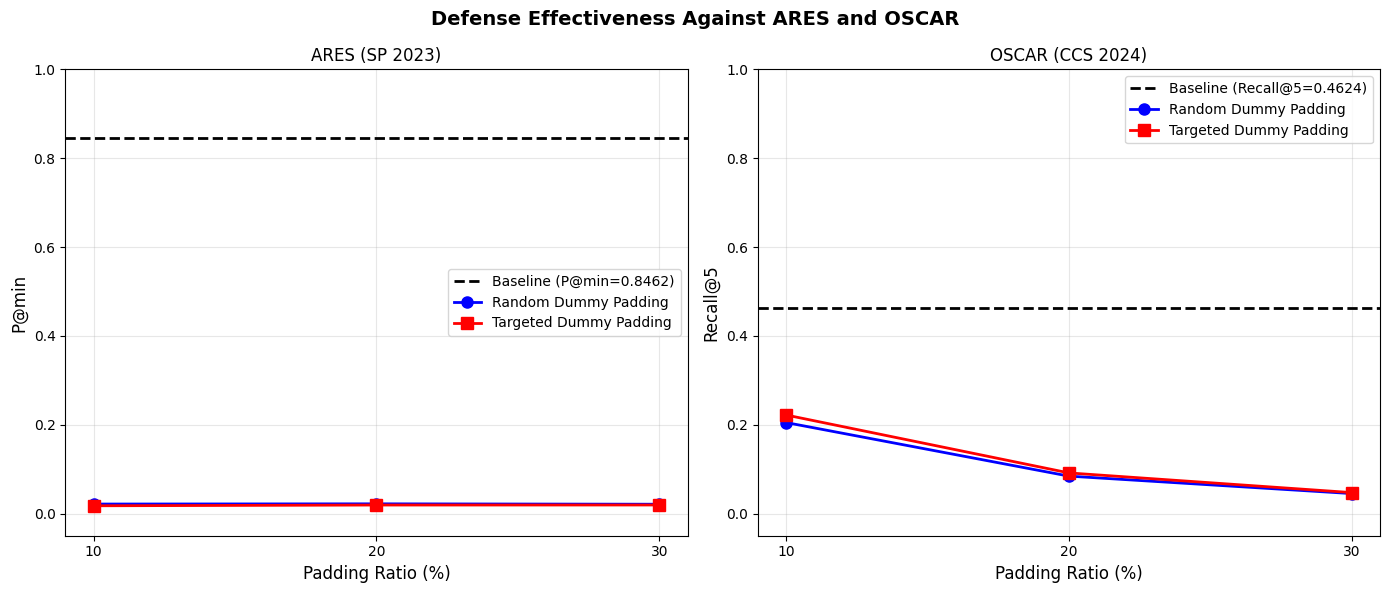

Plot saved to Drive


In [48]:
# Cell 23 - Visualization of defense results
import matplotlib.pyplot as plt
import numpy as np
import os

# Results
results_ares = {
    'baseline': 0.8462,
    'random_dummy_padding_10': 0.0213,
    'random_dummy_padding_20': 0.0218,
    'random_dummy_padding_30': 0.0209,
    'targeted_dummy_padding_10': 0.0174,
    'targeted_dummy_padding_20': 0.0191,
    'targeted_dummy_padding_30': 0.0192
}

results_oscar = {
    'baseline': 0.4624,
    'random_dummy_padding_10': 0.2048,
    'random_dummy_padding_20': 0.0842,
    'random_dummy_padding_30': 0.0449,
    'targeted_dummy_padding_10': 0.2218,
    'targeted_dummy_padding_20': 0.0914,
    'targeted_dummy_padding_30': 0.0471
}

ratios = [10, 20, 30]
random_ares = [results_ares[f'random_dummy_padding_{r}'] for r in ratios]
targeted_ares = [results_ares[f'targeted_dummy_padding_{r}'] for r in ratios]
random_oscar = [results_oscar[f'random_dummy_padding_{r}'] for r in ratios]
targeted_oscar = [results_oscar[f'targeted_dummy_padding_{r}'] for r in ratios]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Defense Effectiveness Against ARES and OSCAR', fontsize=14, fontweight='bold')

# ARES plot
ax1 = axes[0]
ax1.axhline(y=results_ares['baseline'], color='black', linestyle='--',
            linewidth=2, label=f'Baseline (P@min={results_ares["baseline"]})')
ax1.plot(ratios, random_ares, 'bo-', linewidth=2, markersize=8, label='Random Dummy Padding')
ax1.plot(ratios, targeted_ares, 'rs-', linewidth=2, markersize=8, label='Targeted Dummy Padding')
ax1.set_xlabel('Padding Ratio (%)', fontsize=12)
ax1.set_ylabel('P@min', fontsize=12)
ax1.set_title('ARES (SP 2023)', fontsize=12)
ax1.set_xticks(ratios)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.05, 1.0)

# OSCAR plot
ax2 = axes[1]
ax2.axhline(y=results_oscar['baseline'], color='black', linestyle='--',
            linewidth=2, label=f'Baseline (Recall@5={results_oscar["baseline"]})')
ax2.plot(ratios, random_oscar, 'bo-', linewidth=2, markersize=8, label='Random Dummy Padding')
ax2.plot(ratios, targeted_oscar, 'rs-', linewidth=2, markersize=8, label='Targeted Dummy Padding')
ax2.set_xlabel('Padding Ratio (%)', fontsize=12)
ax2.set_ylabel('Recall@5', fontsize=12)
ax2.set_title('OSCAR (CCS 2024)', fontsize=12)
ax2.set_xticks(ratios)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.05, 1.0)

plt.tight_layout()

# Save
os.makedirs('/content/drive/MyDrive/WF_project/results', exist_ok=True)
plt.savefig('/content/drive/MyDrive/WF_project/results/defense_results.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to Drive")

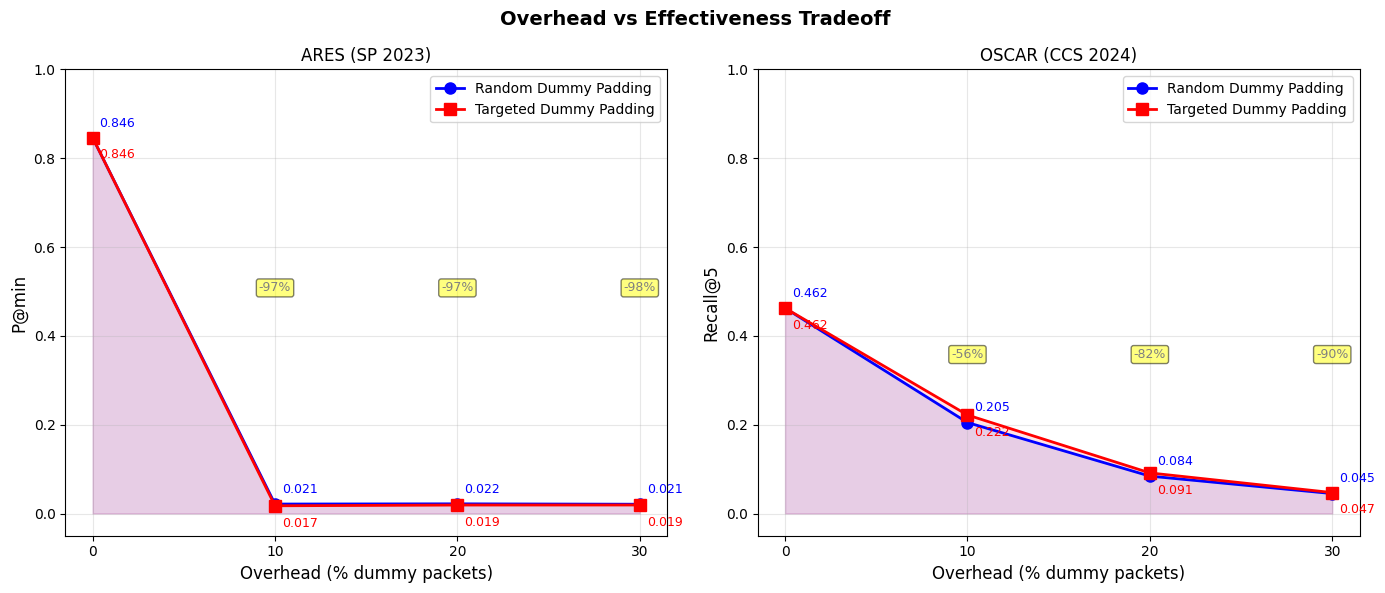

Plot saved to Drive


In [49]:
# Cell 24 - Overhead vs Effectiveness plot
import matplotlib.pyplot as plt
import numpy as np
import os

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Overhead vs Effectiveness Tradeoff', fontsize=14, fontweight='bold')

ratios = [0, 10, 20, 30]

# ARES data
ares_random = [0.8462, 0.0213, 0.0218, 0.0209]
ares_targeted = [0.8462, 0.0174, 0.0191, 0.0192]

# OSCAR data
oscar_random = [0.4624, 0.2048, 0.0842, 0.0449]
oscar_targeted = [0.4624, 0.2218, 0.0914, 0.0471]

# ARES plot
ax1 = axes[0]
ax1.fill_between(ratios, ares_random, alpha=0.1, color='blue')
ax1.fill_between(ratios, ares_targeted, alpha=0.1, color='red')
ax1.plot(ratios, ares_random, 'bo-', linewidth=2, markersize=8, label='Random Dummy Padding')
ax1.plot(ratios, ares_targeted, 'rs-', linewidth=2, markersize=8, label='Targeted Dummy Padding')

# Annotations
for i, r in enumerate(ratios):
    ax1.annotate(f'{ares_random[i]:.3f}', (r, ares_random[i]),
                textcoords="offset points", xytext=(5, 8), fontsize=9, color='blue')
    ax1.annotate(f'{ares_targeted[i]:.3f}', (r, ares_targeted[i]),
                textcoords="offset points", xytext=(5, -15), fontsize=9, color='red')

ax1.set_xlabel('Overhead (% dummy packets)', fontsize=12)
ax1.set_ylabel('P@min', fontsize=12)
ax1.set_title('ARES (SP 2023)', fontsize=12)
ax1.set_xticks(ratios)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.05, 1.0)

# Add reduction percentage annotations
for i, r in enumerate(ratios[1:], 1):
    reduction = (1 - ares_random[i] / ares_random[0]) * 100
    ax1.annotate(f'-{reduction:.0f}%', (r, 0.5),
                ha='center', fontsize=9, color='gray',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.5))

# OSCAR plot
ax2 = axes[1]
ax2.fill_between(ratios, oscar_random, alpha=0.1, color='blue')
ax2.fill_between(ratios, oscar_targeted, alpha=0.1, color='red')
ax2.plot(ratios, oscar_random, 'bo-', linewidth=2, markersize=8, label='Random Dummy Padding')
ax2.plot(ratios, oscar_targeted, 'rs-', linewidth=2, markersize=8, label='Targeted Dummy Padding')

for i, r in enumerate(ratios):
    ax2.annotate(f'{oscar_random[i]:.3f}', (r, oscar_random[i]),
                textcoords="offset points", xytext=(5, 8), fontsize=9, color='blue')
    ax2.annotate(f'{oscar_targeted[i]:.3f}', (r, oscar_targeted[i]),
                textcoords="offset points", xytext=(5, -15), fontsize=9, color='red')

ax2.set_xlabel('Overhead (% dummy packets)', fontsize=12)
ax2.set_ylabel('Recall@5', fontsize=12)
ax2.set_title('OSCAR (CCS 2024)', fontsize=12)
ax2.set_xticks(ratios)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.05, 1.0)

for i, r in enumerate(ratios[1:], 1):
    reduction = (1 - oscar_random[i] / oscar_random[0]) * 100
    ax2.annotate(f'-{reduction:.0f}%', (r, 0.35),
                ha='center', fontsize=9, color='gray',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/WF_project/results/overhead_vs_effectiveness.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to Drive")

In [50]:
# Cell 25 - Setup Git and push to GitHub
import os

# Configure git
!git config --global user.email "zahrarezaei96@gmail.com"
!git config --global user.name "zahrarezaei96"

# Clone the repo
!git clone https://github.com/zahrarezaei96/WF-Defense-Project.git /content/WF-Defense-Project

print("Done")

Cloning into '/content/WF-Defense-Project'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
Done


In [51]:
# Cell 26 - Copy files to repo
import shutil, os

repo_path = '/content/WF-Defense-Project'

# Copy notebook
!cp /content/drive/MyDrive/WF_project/DNS.ipynb {repo_path}/WF_Defense_Notebook.ipynb

# Copy results
os.makedirs(f'{repo_path}/results', exist_ok=True)
!cp /content/drive/MyDrive/WF_project/results/ares_defense_results.json {repo_path}/results/
!cp /content/drive/MyDrive/WF_project/results/oscar_defense_results.json {repo_path}/results/
!cp /content/drive/MyDrive/WF_project/results/defense_results.png {repo_path}/results/
!cp /content/drive/MyDrive/WF_project/results/overhead_vs_effectiveness.png {repo_path}/results/

print("Files copied")
!ls {repo_path}

cp: cannot stat '/content/drive/MyDrive/WF_project/DNS.ipynb': No such file or directory
Files copied
README.md  results
